I am going to try and Predict what Pitch Max Fried Will Throw

In [ ]:
import pandas as pd
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
fried = pd.read_csv('Max_Fried.csv')
fried.head()


,pitch_type,Previous Pitch,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,SI,FF,9/7/25,96.2,1.05,6.09,"Fried, Max",543807,608331,field_out,...,2.0,1.82,0.79,-0.79,49.2,10.643335,11.732483,31.526925,45.550552,18.040702
1,FF,FC,9/7/25,96.2,0.97,6.14,"Fried, Max",664702,608331,field_out,...,2.0,1.15,0.23,-0.23,49.3,7.720645,1.277646,31.718561,33.117742,27.191028
2,FC,SI,9/7/25,94.1,1.21,6.06,"Fried, Max",664702,608331,NaN,...,2.0,1.62,-0.01,0.01,46.9,-1.646519,16.610025,32.840541,32.446668,22.005655
3,SI,CH,9/7/25,90.9,1.61,5.83,"Fried, Max",664702,608331,NaN,...,2.0,2.40,0.80,-0.80,40.9,20.405358,-16.856640,43.623968,29.828033,39.140849
4,CH,CU,9/7/25,83.3,1.68,5.79,"Fried, Max",664702,608331,NaN,...,2.0,3.38,1.50,-1.50,38.8,NaN,NaN,NaN,NaN,NaN


In [ ]:
# list all the columns of the dataset
fried.columns.tolist()

['pitch_type',
 'Previous Pitch',
 'game_date',
 'release_speed',
 'release_pos_x',
 'release_pos_z',
 'player_name',
 'batter',
 'pitcher',
 'events',
 'description',
 'Previou_description',
 'spin_dir',
 'spin_rate_deprecated',
 'break_angle_deprecated',
 'break_length_deprecated',
 'zone',
 'des',
 'game_type',
 'stand',
 'p_throws',
 'home_team',
 'away_team',
 'type',
 'hit_location',
 'bb_type',
 'balls',
 'strikes',
 'game_year',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'on_3b',
 'on_2b',
 'on_1b',
 'outs_when_up',
 'inning',
 'inning_topbot',
 'hc_x',
 'hc_y',
 'tfs_deprecated',
 'tfs_zulu_deprecated',
 'umpire',
 'sv_id',
 'vx0',
 'vy0',
 'vz0',
 'ax',
 'ay',
 'az',
 'sz_top',
 'sz_bot',
 'hit_distance_sc',
 'launch_speed',
 'launch_angle',
 'effective_speed',
 'release_spin_rate',
 'release_extension',
 'game_pk',
 'fielder_2',
 'fielder_3',
 'fielder_4',
 'fielder_5',
 'fielder_6',
 'fielder_7',
 'fielder_8',
 'fielder_9',
 'release_pos_y',
 'estimated_ba_using_speedangl

In [ ]:
features

['Previous Pitch',
 'stand',
 'balls',
 'strikes',
 'outs_when_up',
 'Previou_description',
 'on_1b',
 'on_2b',
 'on_3b']

In [ ]:
fried['on_3b'] = fried['on_3b'].notna()
fried['on_2b'] = fried['on_2b'].notna()
fried['on_1b'] = fried['on_1b'].notna()

display(fried[['on_3b', 'on_2b', 'on_1b']].head())

,on_3b,on_2b,on_1b
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


In [ ]:
features = ['Previous Pitch','stand','balls','strikes','outs_when_up','Previou_description','on_1b','on_2b','on_3b']

In [ ]:
target = 'pitch_type'
y = fried[target]
X = fried[features]

In [ ]:
X = pd.get_dummies(X, columns=['stand', 'Previous Pitch', 'Previou_description'])

In [ ]:
combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)

In [ ]:
X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_Train.shape)
print(y_Train.shape)
print(X_Test.shape)
print(y_Test.shape)

(2244, 28)
(2244,)
(561, 28)
(561,)


In [ ]:
dtree = DecisionTreeClassifier(random_state=42)


In [ ]:
dtree = dtree.fit(X_Train, y_Train)

In [ ]:
dtree

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dtree.predict(X_Test)

In [ ]:
accuracy_score(y_Test, y_pred)

0.3065953654188948

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [ ]:
important_variables = dtree.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': important_variables})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).reset_index(drop=True)

In [ ]:
print(feature_importance_df)

                                        feature  importance
0                                  outs_when_up    0.175012
1                                         on_1b    0.083200
2                                         balls    0.077941
3                                       strikes    0.063148
4                                         on_2b    0.061417
5                                       stand_L    0.056957
6                                         on_3b    0.056897
7                             Previous Pitch_CU    0.045704
8                             Previous Pitch_FF    0.044354
9                             Previous Pitch_SI    0.041658
10                            Previous Pitch_FC    0.038377
11            Previou_description_called_strike    0.037078
12                     Previou_description_foul    0.036753
13                            Previous Pitch_ST    0.035408
14                     Previou_description_ball    0.034623
15          Previou_description_swinging

In [ ]:
import seaborn as sns

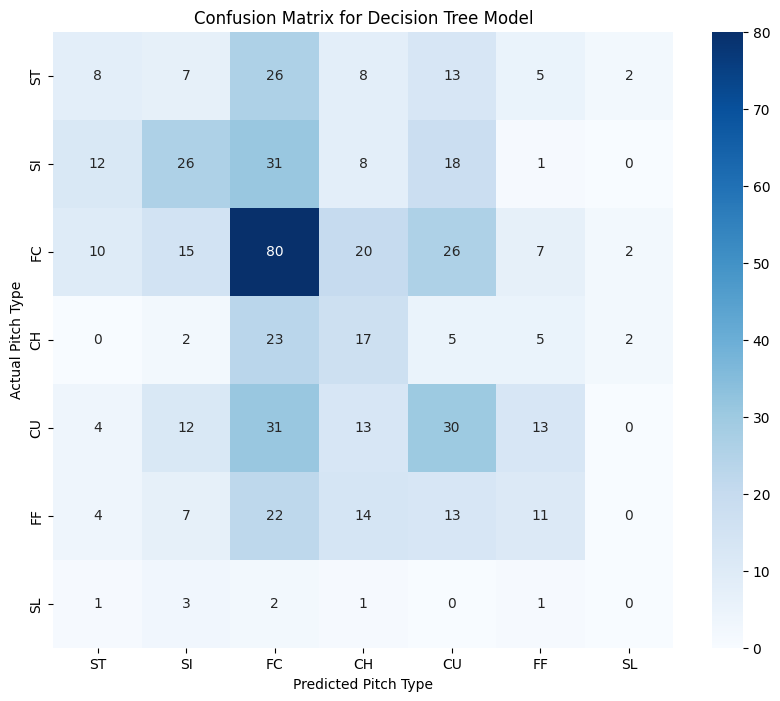

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the unique pitch types to use as labels
pitch_types = y_Test.unique()

# Calculate the confusion matrix for the Decision Tree model
cm_dtree = confusion_matrix(y_Test, y_pred, labels=pitch_types)

# Create a DataFrame from the confusion matrix for better visualization
cm_df_dtree = pd.DataFrame(cm_dtree, index=pitch_types, columns=pitch_types)

# Plot the confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_dtree, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Decision Tree Model')
plt.xlabel('Predicted Pitch Type')
plt.ylabel('Actual Pitch Type')
plt.show()